# Конструирование алгоритмов `lscp`

In [47]:
import numpy as np
import networkx as nx
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox

from genesis.core import BestPointsBase, MetricBase, StateBase, StopCaseBase, LSCPBase, PointSelectorBase
from genesis.best_points import BestNodeHillClimbing, NodeMetric
from genesis.states import FirstArrivalUnitState
from genesis.metrics import ArrivalTime, CoverIndex
from genesis.mclp import BestNodesKoptG
from genesis.tools import list_dict_concat, get_dict_key
from genesis.utils import timing
from genesis.swiss_knife import CMAP_GrGldRd
from genesis.point_selectors import GenesisNodeSelector, RandomNodesSelector

In [48]:
# Загрузка графа и полигона границ
G = ox.load_graphml("tests/data/test_rng.ml")
area = gpd.read_file("tests/data/test_polygon.gpkg")

In [49]:
def iter_state_func(**kwds):
    '''
    Печать состояния расчета на итерации
    '''
    # print('Итерация:', kwds['i'])
    print(kwds)
    dynamic_nodes = kwds['dynamic_nodes']
    if isinstance(dynamic_nodes, dict):
        dynamic_nodes_id = list(dynamic_nodes.keys())
    else:
        dynamic_nodes_id = dynamic_nodes

    try:
        static_nodes = kwds['static_nodes']
        if isinstance(static_nodes, dict):
            static_nodes_id = list(static_nodes.keys())
        else:
            static_nodes_id = static_nodes
    except:
        static_nodes = None
        
    if not static_nodes is None:
        if isinstance(dynamic_nodes,list):
            start_nodes = dynamic_nodes+static_nodes
        elif isinstance(dynamic_nodes,dict):
            start_nodes = {**dynamic_nodes, **static_nodes}
    else:
        start_nodes = dynamic_nodes
    times, nearest = FirstArrivalUnitState()(env=G, points=start_nodes)
    times = {k:(1+int(t//5))*5 for k, t in times.items()}

    nx.set_node_attributes(G, pd.Series(nearest, dtype=str), 'nearest')
    nx.set_node_attributes(G, times, 'route_time')

    nds = ox.graph_to_gdfs(G, edges=False)
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))
    ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax1)
    nds.plot(ax=ax1, markersize=2, column='nearest', cmap='Set3', legend=True)
    nds.loc[dynamic_nodes_id].plot(ax=ax1, markersize=25, color='red')
    if static_nodes:
        nds.loc[static_nodes_id].plot(ax=ax1, markersize=25, color='k')

    ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax2)
    nds.plot(ax=ax2, markersize=2, column='route_time', cmap=CMAP_GrGldRd, legend=True)
    nds.loc[dynamic_nodes_id].plot(ax=ax2, markersize=25, color='red')
    if static_nodes:
        nds.loc[static_nodes_id].plot(ax=ax2, markersize=25, color='k')

    plt.show()

def iter_func(**kwds):
    'Функция вывода хода расчета'
    print(kwds)

# Разработка

In [67]:
class LSCPCommon(LSCPBase):
    '''
    Наиболее общий модульный алгоритм расчета количества и оптимального 
    размещения узлов для достижения целевой метрики.
    '''
    def __init__(self,
                 mclp_function: BestPointsBase,
                 point_selector: PointSelectorBase,
                 stop_case_function: StopCaseBase,
                 names_pattern: str = '{}',
                 start_names_index: int = 1,
                 after_mclp_function: callable = None,
                 **kwargs):
        self.after_mclp_function = after_mclp_function
        super().__init__(mclp_function, point_selector, stop_case_function, names_pattern, start_names_index, **kwargs)

    def __call__(self,
                 env:nx.MultiDiGraph,
                 dynamic_nodes: dict,
                 static_nodes: dict = None,
                 area: pd.Series = None,
                 **kwargs):
        '''
        Запуск работы алгоритма

        ## Аргументы
        `env`:nx.MultiDiGraph
            Граф улично-дорожной сети
        `dynamic_nodes`: list|dict
            Список стартовых узлов графа в которых размещены
            подразделения оптимальные места которых следует определить.
        `static_nodes`: list|dict = None
            Список стартовых узлов графа в которых размещены
            подразделения изменять размещение которых не следует.
        `area`: pd.Series = None
            Маска узлов графа. Значениями True отмечены узлы графа - цели расчета леса Вороного.
            Если не указана, расчет производится для всех узлов графа.
        '''

        # 0. Проверка корректности пришедших данных
        if not isinstance(env, nx.MultiDiGraph):
            raise TypeError("Тип аргумента `env` должен быть MultiDiGraph!")
        if not static_nodes is None:
            if not (isinstance(dynamic_nodes,dict) and isinstance(static_nodes,dict)):
                raise TypeError(f'Аргументы `dynamic_nodes` и `static_nodes` должны быть одинакового типа: dict'
                                f'Имеют: {type(dynamic_nodes)}, {type(static_nodes)}')
        if not area is None and not isinstance(area, pd.Series):
            raise TypeError(f'Аргумент `area` должен иметь тип `pd.Series`! Имеет {type(area)}')
      
        # 0.1. Если статические узлы не указаны - заменяем значение переменной с None на {}
        if static_nodes is None:
            static_nodes = {}
        if len(static_nodes) + len(dynamic_nodes) == 0:
            raise ValueError('Суммарное количество элементов `static_nodes` и `dynamic_nodes` не может быть равно 0! ' + \
                            'В случае если в `env` отсутствуют известные размещения `points`, ' + \
                            'используйте методы класса `BestPointsBase`')

        # Итерации
        best_dynamic_nodes = dynamic_nodes
        iteration = 0
        name_index = self.start_names_index
        while True:
            # 1. Расчет оптимального размещения подразделений
            best_dynamic_nodes, best_metric = self.mclp_function(env=env,
                                            dynamic_nodes=best_dynamic_nodes,
                                            static_nodes=static_nodes,
                                            area=area,
                                            **kwargs)
            if not self.after_mclp_function is None:
                self.after_mclp_function(iteration=iteration,
                            best_metric=best_metric,
                            dynamic_nodes=best_dynamic_nodes,
                            static_nodes=static_nodes)

            # 2. Если достигнута цель расчета, выходим из цикла
            if self.stop_case_function(value=best_metric,
                            iteration=iteration,
                            best_metric=best_metric,
                            dynamic_nodes=best_dynamic_nodes,
                            static_nodes=static_nodes):
                return best_dynamic_nodes, best_metric

            # ============================================================================================
            # 2. Если нет - создаем новое подразделение
            # 2.1. Получение суммарного списка (или словаря) узлов для расчета состояния и метрик
            start_nodes = list_dict_concat(dynamic_nodes, static_nodes)

            # 2.2. Выбор нового узла в соответствии с переданной логикой
            new_node = self.point_selector(env, start_nodes)

            # 2.3. Добавление нового узла в словарь динамических узлов:
            print(best_dynamic_nodes, new_node, iteration)
            best_dynamic_nodes[new_node] = self.names_pattern.format(name_index)

            # # 3. Расчет оптимального размещения подразделений
            # best_dynamic_nodes, best_metric = self.mclp_function(env=env,
            #                                 dynamic_nodes=best_dynamic_nodes,
            #                                 static_nodes=static_nodes,
            #                                 area=area,
            #                                 **kwargs)

            # ============================================================================================
            iteration += 1
            name_index += 1

        return best_dynamic_nodes, best_metric


In [51]:
class ItersStopCase(StopCaseBase):
    '''
    Критерий остановки по условию, что на протяжении нескольких итераций
    значения равны, т.е. не изменяются
    '''
    def __init__(self, max_iter_count=2):
        self.max_iter_count = max_iter_count

    def __call__(self, **kwargs):
        print(kwargs)
        iters_count = kwargs['iteration']
        
        return iters_count>=self.max_iter_count

def mclp_end_function(iteration, best_metric, **kwargs):
    print(f'Итерация: {iteration} |', f'Лучшая метрика: {best_metric} |')


# Определение маски расчета
nodes = ox.graph_to_gdfs(G, edges=False)
points_mask = nodes.within(area.iloc[0].geometry)


nodes = list(G.nodes())
existed_units = {nodes[100]:'A', 
                nodes[2000]:'B', 
                }
new_units = {nodes[3000]:'c',
             nodes[4000]:'d'}


# Функция расчета лучшего узла в графе
BNHC = BestNodeHillClimbing(state_function = FirstArrivalUnitState(),
                            metric_function = ArrivalTime())
# Функция расчета лучшего размещения заданных узлов
BNG = BestNodesKoptG(state_function = FirstArrivalUnitState(),
                    metric_function = ArrivalTime(),
                    best_point_function = BNHC,
                    iterations = 5,
                    )
# Критерий остановки
stop_case = ItersStopCase(max_iter_count = 2)
# Селектор следующей точки
# point_selector = RandomNodesSelector()
point_selector = GenesisNodeSelector(state_function = FirstArrivalUnitState(),
                                     metric_function = ArrivalTime())


# Сборка алгоритма
genesis = timing(LSCPCommon(mclp_function = BNG,
                     point_selector = point_selector,
                    stop_case_function = stop_case,
                    start_names_index = 5,
                    names_pattern='ПСЧ {}',
                    after_mclp_function=mclp_end_function,
                    ))

# Собственно применения построенного алгоритма
best_dynamic_nodes, metric = genesis(env = G,
                                dynamic_nodes = new_units,
                                static_nodes = existed_units)
print('='*80)
print('Лучшие узлы:')
print(best_dynamic_nodes)
print(f'Метрика: {metric}')

Итерация: 0 | Лучшая метрика: 6.984608999416008 |
{'value': 6.984608999416008, 'iteration': 0, 'best_metric': 6.984608999416008, 'dynamic_nodes': {4116059950: 'c', 5116722296: 'd'}, 'static_nodes': {1296599762: 'A', 2042076750: 'B'}}
{4116059950: 'c', 5116722296: 'd'} 2042076753 0
Итерация: 1 | Лучшая метрика: 4.667819914049523 |
{'value': 4.667819914049523, 'iteration': 1, 'best_metric': 4.667819914049523, 'dynamic_nodes': {4116059950: 'c', 5116722296: 'd', 2034401761: 'ПСЧ 5'}, 'static_nodes': {1296599762: 'A', 2042076750: 'B'}}
{4116059950: 'c', 5116722296: 'd', 2034401761: 'ПСЧ 5'} 2042076753 1
Итерация: 2 | Лучшая метрика: 4.526682571130086 |
{'value': 4.526682571130086, 'iteration': 2, 'best_metric': 4.526682571130086, 'dynamic_nodes': {4116059950: 'c', 5116722296: 'd', 2034401777: 'ПСЧ 5', 2054469107: 'ПСЧ 6'}, 'static_nodes': {1296599762: 'A', 2042076750: 'B'}}
ВРЕМЯ: 13.04 сек
Лучшие узлы:
{4116059950: 'c', 5116722296: 'd', 2034401777: 'ПСЧ 5', 2054469107: 'ПСЧ 6'}
Метрика: 4.

{'dynamic_nodes': {4116059950: 'c', 5116722296: 'd', 2034401777: 'ПСЧ 5', 2054469107: 'ПСЧ 6'}, 'static_nodes': {1296599762: 'A', 2042076750: 'B'}}


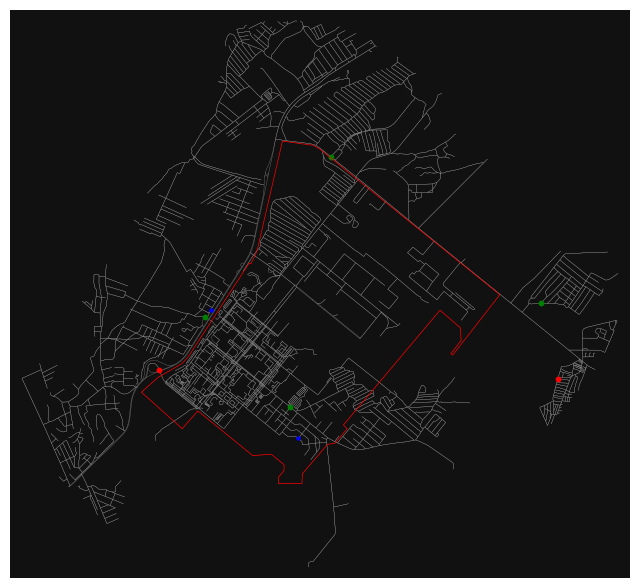

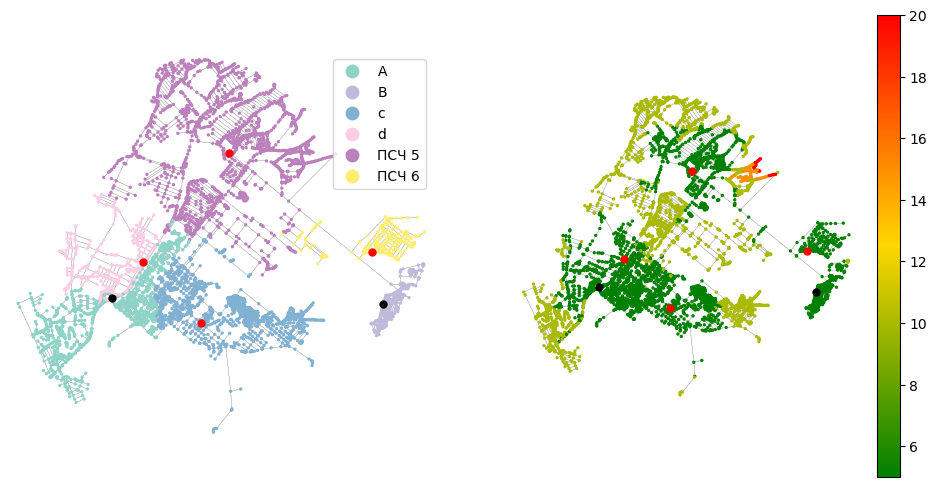

In [53]:
g_nodes_gdf = ox.graph_to_gdfs(G, edges=False)

# start_units = {**existed_units, **new_units}

fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False)
g_nodes_gdf.loc[best_dynamic_nodes.keys()].plot(ax=ax, c='g', markersize=10)
g_nodes_gdf.loc[existed_units.keys()].plot(ax=ax, c='r', markersize=10)
g_nodes_gdf.loc[new_units.keys()].plot(ax=ax, c='b', markersize=5)
area.boundary.plot(ax=ax, color='r', linewidth=0.5)

iter_state_func(dynamic_nodes=best_dynamic_nodes, static_nodes=existed_units)

## ГА и выбор случайных узлов

In [54]:
# Функция расчета лучшего узла в графе
from genesis.mclp import BestNodesGA

def epoch_end_function(epoch, best_metric, cur_metric, **kwargs):
    print(f'Эпоха: {epoch} |', f'Лучшая метрика: {best_metric} |', f'Текущая метрика: {cur_metric} |')

MCLP = BestNodesGA(state_function = FirstArrivalUnitState(),
                    metric_function = ArrivalTime(),
                    epoch_end_function = epoch_end_function,
                    population_size=50,
                    epochs = 10,
                    )
# Критерий остановки
stop_case = ItersStopCase(max_iter_count = 2)
# Селектор следующей точки
point_selector = RandomNodesSelector()


# Сборка алгоритма
genesis = LSCPCommon(mclp_function = MCLP,
                     point_selector = point_selector,
                    stop_case_function = stop_case,
                    after_mclp_function=mclp_end_function,
                    )

# Собственно применения построенного алгоритма
best_dynamic_nodes, metric = genesis(env = G,
                                dynamic_nodes = new_units,
                                static_nodes = existed_units)
print('='*80)
print('Лучшие узлы:')
print(best_dynamic_nodes)
print(f'Метрика: {metric}')

Эпоха: 0 | Лучшая метрика: 5.532002402395659 | Текущая метрика: 5.532002402395659 |
Эпоха: 1 | Лучшая метрика: 5.532002402395659 | Текущая метрика: 5.5610454915515986 |
Эпоха: 2 | Лучшая метрика: 5.280449286635693 | Текущая метрика: 5.280449286635693 |
Эпоха: 3 | Лучшая метрика: 5.168440666722903 | Текущая метрика: 5.168440666722903 |
Эпоха: 4 | Лучшая метрика: 5.168440666722903 | Текущая метрика: 5.280449286635693 |
Эпоха: 5 | Лучшая метрика: 5.168440666722903 | Текущая метрика: 5.251270662985362 |
Эпоха: 6 | Лучшая метрика: 5.168440666722903 | Текущая метрика: 5.280449286635693 |
Эпоха: 7 | Лучшая метрика: 5.168440666722903 | Текущая метрика: 5.179854202177637 |
Эпоха: 8 | Лучшая метрика: 5.168440666722903 | Текущая метрика: 5.2504311610517025 |
Эпоха: 9 | Лучшая метрика: 5.168440666722903 | Текущая метрика: 5.173118419707745 |
Итерация: 0 | Лучшая метрика: 5.168440666722903 |
{'value': 5.168440666722903, 'iteration': 0, 'best_metric': 5.168440666722903, 'dynamic_nodes': {2034401863:

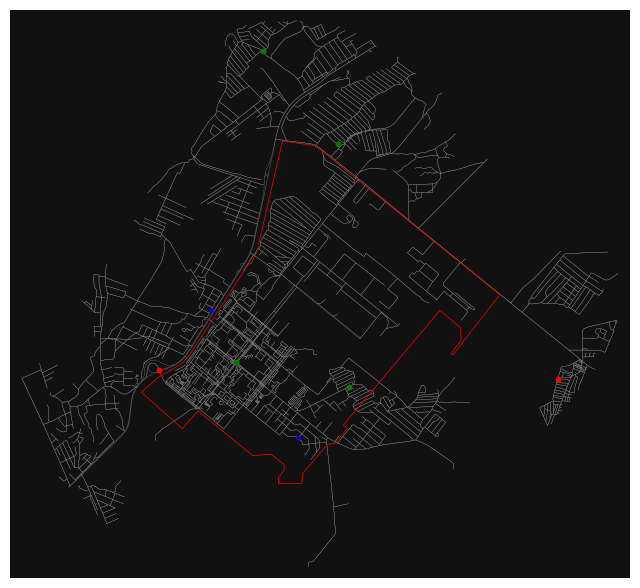

{'dynamic_nodes': {2034401863: 'd', 1998227440: 'c', 2054468910: '1', 2034402581: '2'}, 'static_nodes': {1296599762: 'A', 2042076750: 'B'}}


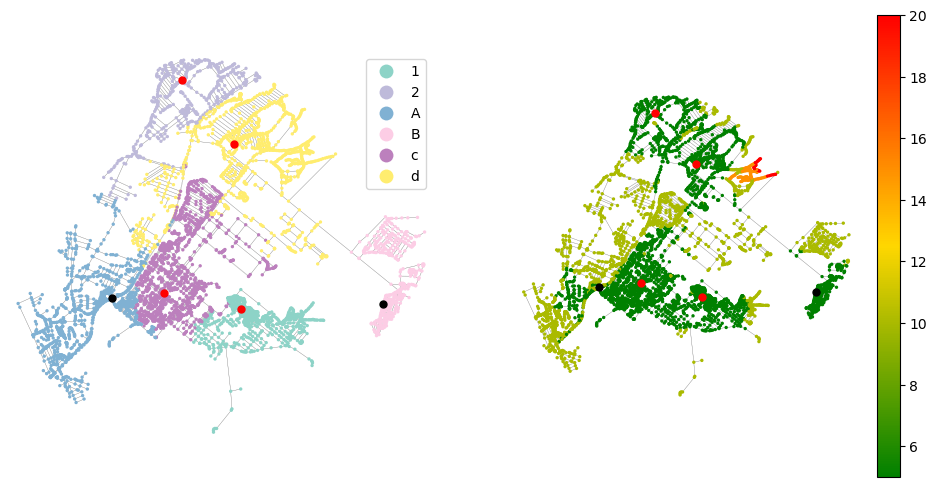

In [55]:
g_nodes_gdf = ox.graph_to_gdfs(G, edges=False)

# start_units = {**existed_units, **new_units}

fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False)
g_nodes_gdf.loc[best_dynamic_nodes.keys()].plot(ax=ax, c='g', markersize=10)
g_nodes_gdf.loc[existed_units.keys()].plot(ax=ax, c='r', markersize=10)
g_nodes_gdf.loc[new_units.keys()].plot(ax=ax, c='b', markersize=5)
area.boundary.plot(ax=ax, color='r', linewidth=0.5)

plt.show()

# ============================================================================================
iter_state_func(dynamic_nodes=best_dynamic_nodes, static_nodes=existed_units)

## ГА и выбор худшего узла

In [56]:
# Функция расчета лучшего узла в графе
from genesis.mclp import BestNodesGA
from genesis.point_selectors import FarNodeSelector

def epoch_end_function(epoch, best_metric, cur_metric, **kwargs):
    print(f'Эпоха: {epoch} |', f'Лучшая метрика: {best_metric} |', f'Текущая метрика: {cur_metric} |')

MCLP = BestNodesGA(state_function = FirstArrivalUnitState(),
                    metric_function = ArrivalTime(),
                    epoch_end_function = epoch_end_function,
                    population_size=50,
                    epochs = 10,
                    )
# Критерий остановки
stop_case = ItersStopCase(max_iter_count = 2)
# Селектор следующей точки
point_selector = FarNodeSelector(FirstArrivalUnitState())


# Сборка алгоритма
genesis = LSCPCommon(mclp_function = MCLP,
                     point_selector = point_selector,
                    stop_case_function = stop_case,
                    after_mclp_function=mclp_end_function,
                    # names_pattern='{}',
                    )

# Собственно применения построенного алгоритма
best_dynamic_nodes, metric = genesis(env = G,
                                dynamic_nodes = new_units,
                                static_nodes = existed_units)
print('='*80)
print('Лучшие узлы:')
print(best_dynamic_nodes)
print(f'Метрика: {metric}')

Эпоха: 0 | Лучшая метрика: 5.173419032223318 | Текущая метрика: 5.173419032223318 |
Эпоха: 1 | Лучшая метрика: 5.173419032223318 | Текущая метрика: 5.326824622988476 |
Эпоха: 2 | Лучшая метрика: 5.173419032223318 | Текущая метрика: 5.205436462663518 |
Эпоха: 3 | Лучшая метрика: 5.173419032223318 | Текущая метрика: 5.208942849057828 |
Эпоха: 4 | Лучшая метрика: 5.173419032223318 | Текущая метрика: 5.3065247193859015 |
Эпоха: 5 | Лучшая метрика: 5.173419032223318 | Текущая метрика: 5.2208954722799 |
Эпоха: 6 | Лучшая метрика: 5.173419032223318 | Текущая метрика: 5.2208954722799 |
Эпоха: 7 | Лучшая метрика: 5.173419032223318 | Текущая метрика: 5.189470698608803 |
Эпоха: 8 | Лучшая метрика: 5.173419032223318 | Текущая метрика: 5.2626036069741495 |
Эпоха: 9 | Лучшая метрика: 5.173419032223318 | Текущая метрика: 5.362297989475187 |
Итерация: 0 | Лучшая метрика: 5.173419032223318 |
{'value': 5.173419032223318, 'iteration': 0, 'best_metric': 5.173419032223318, 'dynamic_nodes': {2760591335: 'c'

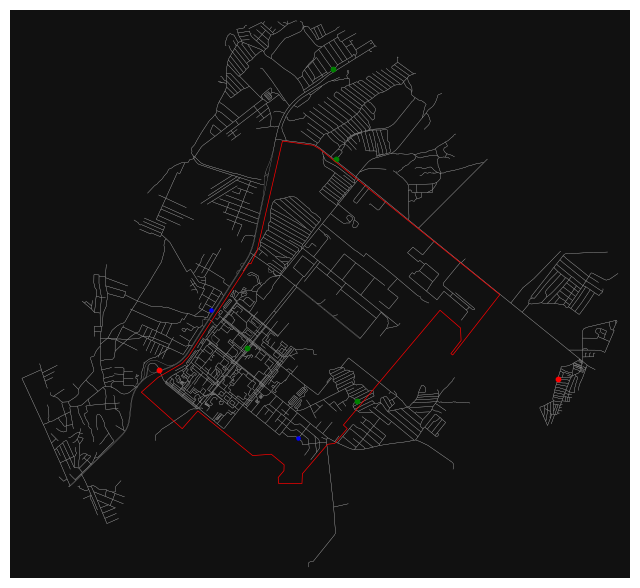

{'dynamic_nodes': {2034402454: '1', 2054468661: 'c', 2034401763: 'd', 1998227467: '2'}, 'static_nodes': {1296599762: 'A', 2042076750: 'B'}}


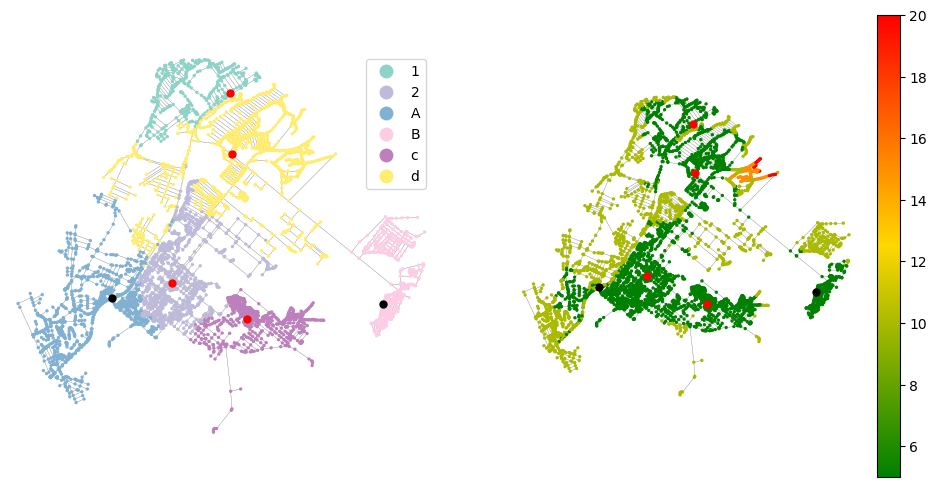

In [57]:
g_nodes_gdf = ox.graph_to_gdfs(G, edges=False)

# start_units = {**existed_units, **new_units}

fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False)
g_nodes_gdf.loc[best_dynamic_nodes.keys()].plot(ax=ax, c='g', markersize=10)
g_nodes_gdf.loc[existed_units.keys()].plot(ax=ax, c='r', markersize=10)
g_nodes_gdf.loc[new_units.keys()].plot(ax=ax, c='b', markersize=5)
area.boundary.plot(ax=ax, color='r', linewidth=0.5)

plt.show()

# ============================================================================================
iter_state_func(dynamic_nodes=best_dynamic_nodes, static_nodes=existed_units)

## С учетом area

In [72]:
# Функция расчета лучшего узла в графе
from genesis.mclp import BestNodesGA
from genesis.point_selectors import FarNodeSelector

def epoch_end_function(epoch, best_metric, cur_metric, **kwargs):
    print(f'Эпоха: {epoch} |', f'Лучшая метрика: {best_metric} |', f'Текущая метрика: {cur_metric} |')

MCLP = BestNodesGA(state_function = FirstArrivalUnitState(),
                    metric_function = ArrivalTime(),
                    epoch_end_function = epoch_end_function,
                    population_size=25,
                    epochs = 5,
                    )
# Критерий остановки
stop_case = ItersStopCase(max_iter_count = 2)
# Селектор следующей точки
point_selector = FarNodeSelector(FirstArrivalUnitState())


# Сборка алгоритма
genesis = LSCPCommon(mclp_function = MCLP,
                     point_selector = point_selector,
                    stop_case_function = stop_case,
                    after_mclp_function=mclp_end_function,
                    # names_pattern='{}',
                    )

# Собственно применения построенного алгоритма
best_dynamic_nodes, metric = genesis(env = G,
                                dynamic_nodes = new_units,
                                static_nodes = existed_units,
                                area = points_mask)
print('='*80)
print('Лучшие узлы:')
print(best_dynamic_nodes)
print(f'Метрика: {metric}')

Эпоха: 0 | Лучшая метрика: 4.645655879973178 | Текущая метрика: 4.645655879973178 |
Эпоха: 1 | Лучшая метрика: 3.759171641835366 | Текущая метрика: 3.759171641835366 |
Эпоха: 2 | Лучшая метрика: 3.759171641835366 | Текущая метрика: 3.759171641835366 |
Эпоха: 3 | Лучшая метрика: 3.759171641835366 | Текущая метрика: 3.759171641835366 |
Эпоха: 4 | Лучшая метрика: 3.759171641835366 | Текущая метрика: 3.759171641835366 |
Итерация: 0 | Лучшая метрика: 3.759171641835366 |
{'value': 3.759171641835366, 'iteration': 0, 'best_metric': 3.759171641835366, 'dynamic_nodes': {2760591335: 'c', 2034401369: 'd'}, 'static_nodes': {1296599762: 'A', 2042076750: 'B'}}
{2760591335: 'c', 2034401369: 'd'} 10816268041 0
Эпоха: 0 | Лучшая метрика: 3.364770947027268 | Текущая метрика: 3.364770947027268 |
Эпоха: 1 | Лучшая метрика: 3.364770947027268 | Текущая метрика: 3.7023090737275686 |
Эпоха: 2 | Лучшая метрика: 3.364770947027268 | Текущая метрика: 3.7023090737275686 |
Эпоха: 3 | Лучшая метрика: 3.36477094702726

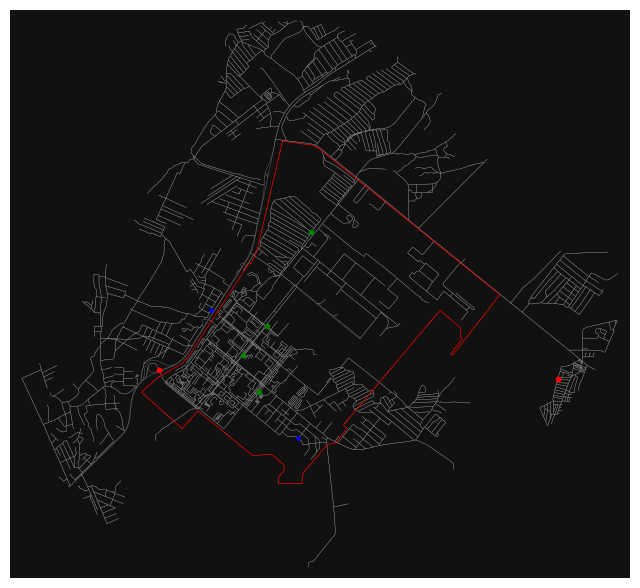

{'dynamic_nodes': {9085465239: 'd', 5574240399: '1', 2034401471: 'c', 9086101138: '2'}, 'static_nodes': {1296599762: 'A', 2042076750: 'B'}}


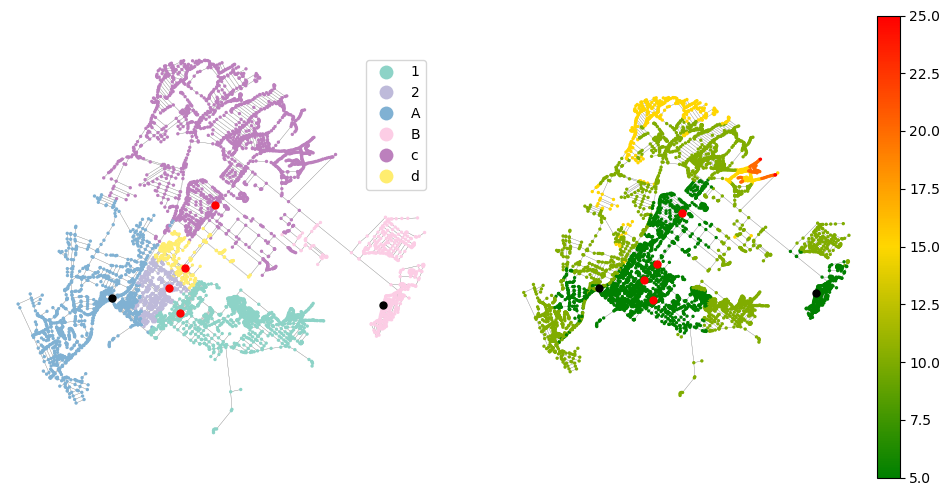

In [71]:
g_nodes_gdf = ox.graph_to_gdfs(G, edges=False)

# start_units = {**existed_units, **new_units}

fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False)
g_nodes_gdf.loc[best_dynamic_nodes.keys()].plot(ax=ax, c='g', markersize=10)
g_nodes_gdf.loc[existed_units.keys()].plot(ax=ax, c='r', markersize=10)
g_nodes_gdf.loc[new_units.keys()].plot(ax=ax, c='b', markersize=5)
area.boundary.plot(ax=ax, color='r', linewidth=0.5)

plt.show()

# ============================================================================================
iter_state_func(dynamic_nodes=best_dynamic_nodes, static_nodes=existed_units)

### Проверка на работоспособность без existed_units

In [60]:
best_dynamic_nodes, metric = genesis(env = G,
                                dynamic_nodes = new_units,
                                # static_nodes = existed_units,
                                area = points_mask)

Эпоха: 0 | Лучшая метрика: 4.910110050865317 | Текущая метрика: 4.910110050865317 |
Эпоха: 1 | Лучшая метрика: 4.196592176352258 | Текущая метрика: 4.196592176352258 |
Эпоха: 2 | Лучшая метрика: 3.90313193048726 | Текущая метрика: 3.90313193048726 |
Эпоха: 3 | Лучшая метрика: 3.90313193048726 | Текущая метрика: 4.200756408614854 |
Эпоха: 4 | Лучшая метрика: 3.90313193048726 | Текущая метрика: 4.286636016380356 |
Эпоха: 5 | Лучшая метрика: 3.90313193048726 | Текущая метрика: 4.231512917715052 |
Эпоха: 6 | Лучшая метрика: 3.90313193048726 | Текущая метрика: 4.10916196676033 |
Эпоха: 7 | Лучшая метрика: 3.90313193048726 | Текущая метрика: 4.184782795740469 |
Эпоха: 8 | Лучшая метрика: 3.90313193048726 | Текущая метрика: 4.3952160970368475 |
Эпоха: 9 | Лучшая метрика: 3.90313193048726 | Текущая метрика: 4.037278981001341 |
Итерация: 0 | Лучшая метрика: 3.90313193048726 |
{'value': 3.90313193048726, 'iteration': 0, 'best_metric': 3.90313193048726, 'dynamic_nodes': {2034401353: 'd', 15456201

### Проверка на работоспособность без подразделений вообще

In [70]:
best_dynamic_nodes, metric = genesis(env = G,
                                dynamic_nodes = {},
                                # static_nodes = existed_units,
                                area = points_mask)

ValueError: Суммарное количество элементов `static_nodes` и `dynamic_nodes` не может быть равно 0! В случае если в `env` отсутствуют известные размещения `points`, используйте методы класса `BestPointsBase`